In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
import mpl_toolkits.mplot3d as Axes3D
from matplotlib.transforms import offset_copy
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import norm
import os
import json

1、Integrated Matrix

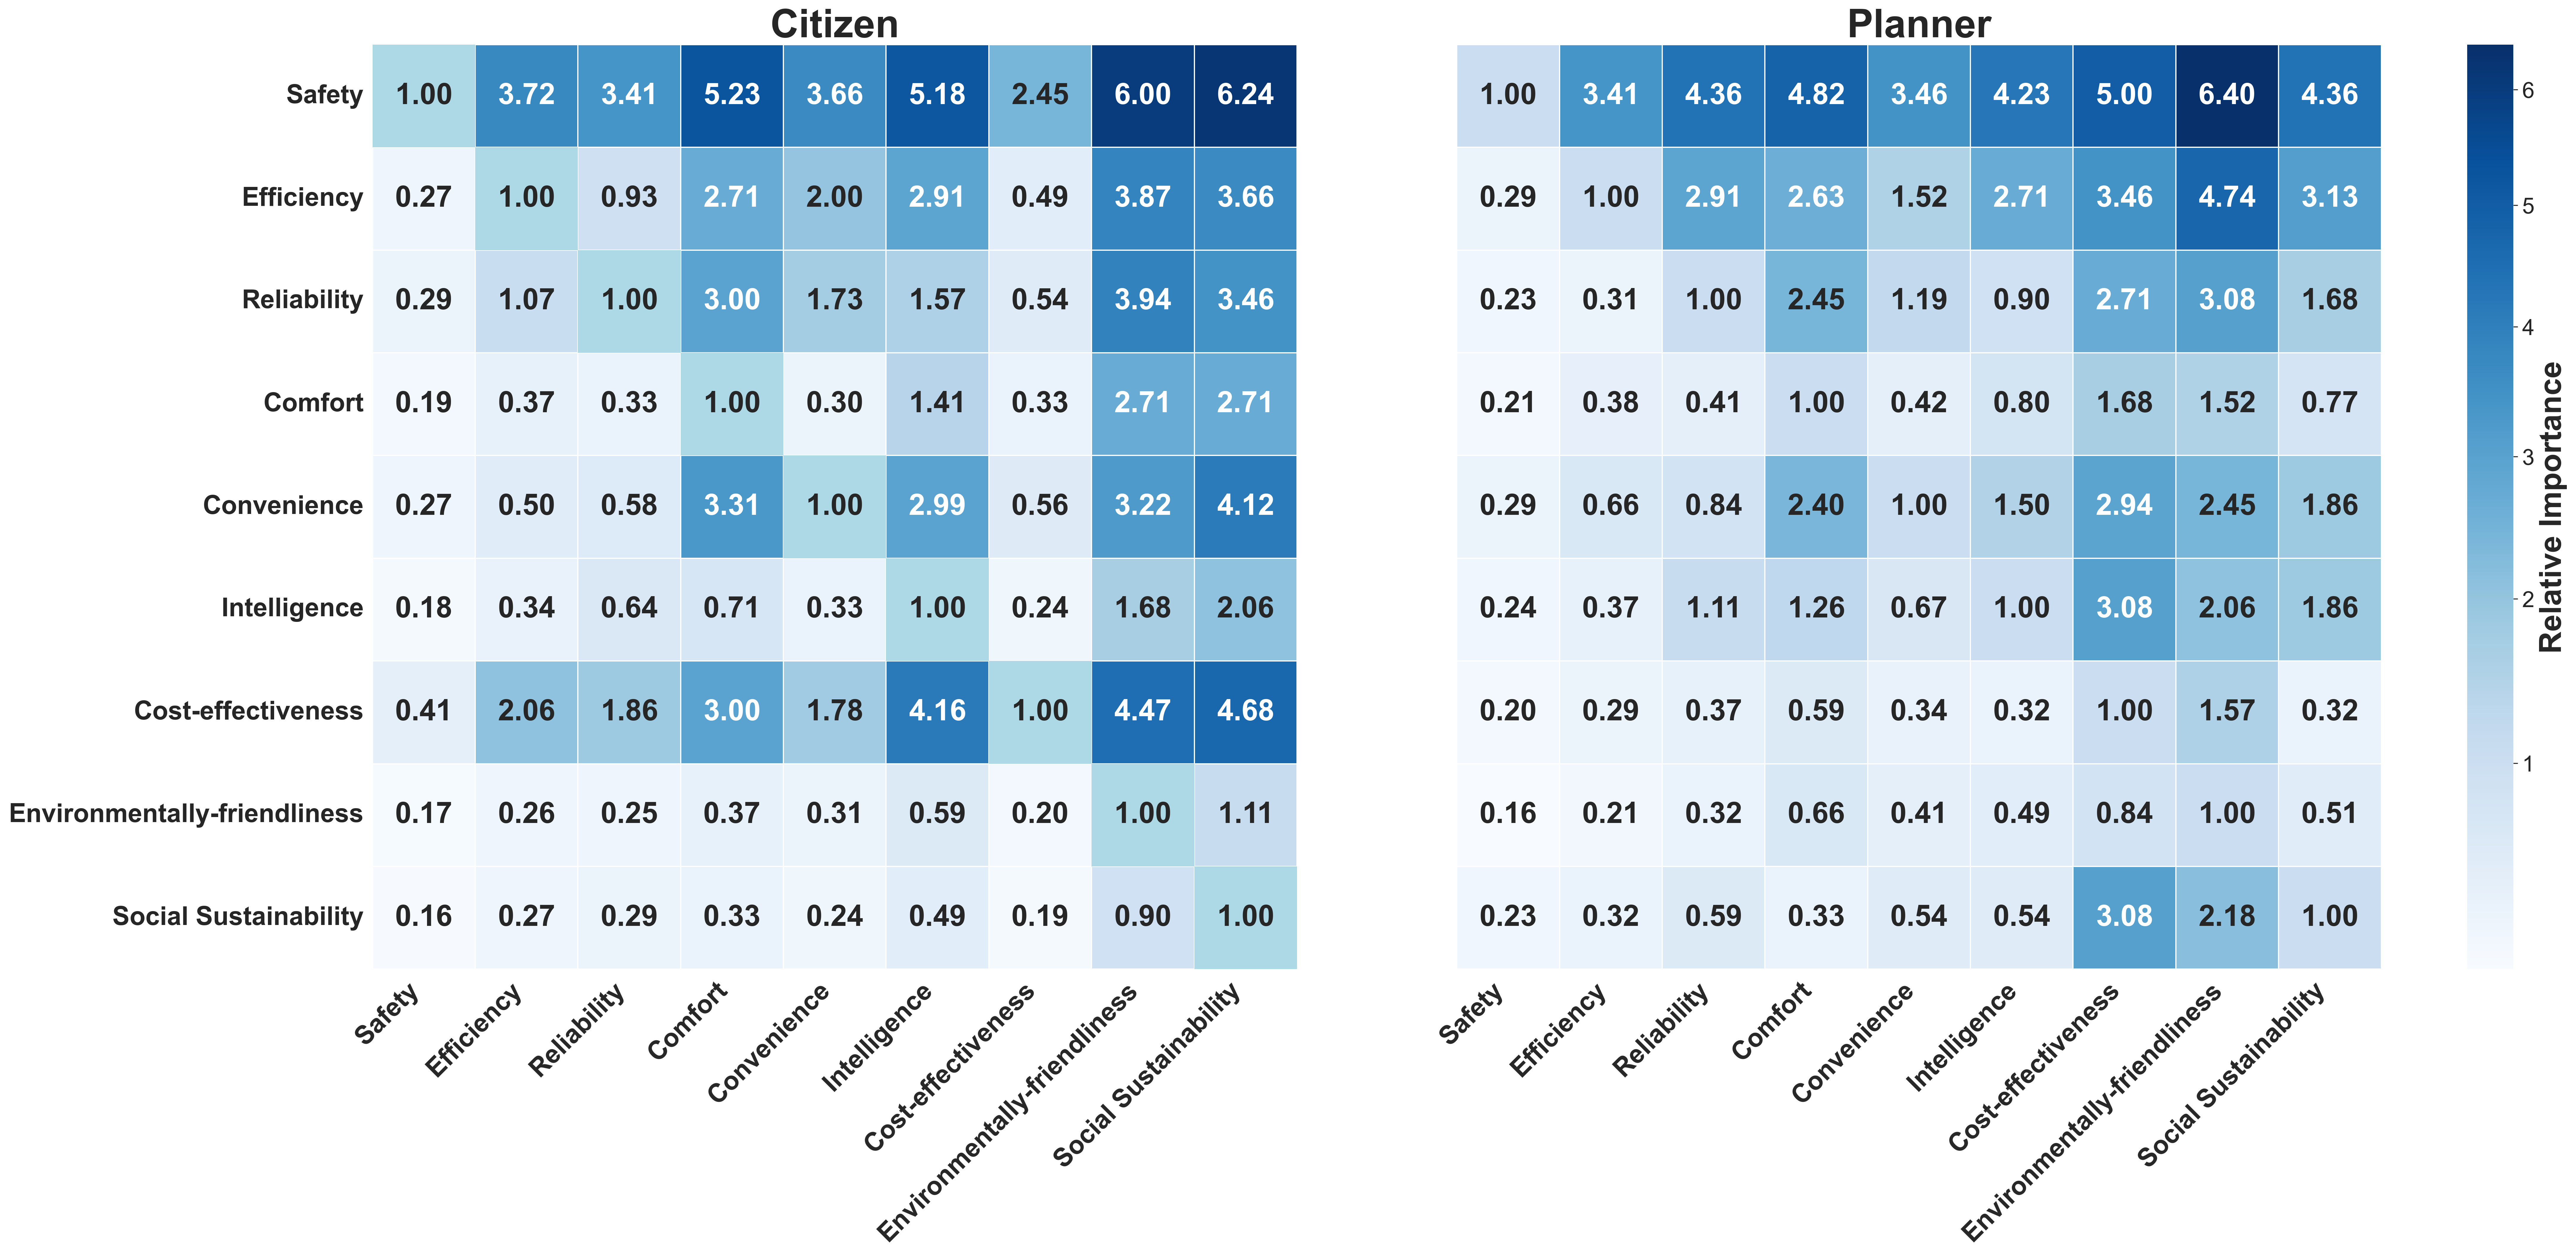

In [2]:
xls1 = pd.ExcelFile('weights_citizen.xlsx')
xls2 = pd.ExcelFile('weights_planner.xlsx')

# 获取所有表名
sheets = xls1.sheet_names

# 初始化矩阵列表
matrices_citizen = []
matrices_planner = []

# 读取数据并转换为矩阵
for sheet in sheets:
    data_citizen = pd.read_excel(xls1, sheet_name=sheet, header=None, skiprows=1, usecols=list(range(1, 10))).values.astype(float)
    matrices_citizen.append(data_citizen)

    data_planner = pd.read_excel(xls2, sheet_name=sheet, header=None, skiprows=1, usecols=list(range(1, 10))).values.astype(float)
    matrices_planner.append(data_planner)

# 计算几何平均和谐均值矩阵
def compute_matrix(matrices):
    num_models = len(matrices)
    n = matrices[0].shape[0]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            values = [m[i][j] for m in matrices]
            M[i][j] = np.prod(values)**(1/num_models)
    return M

M_citizen = compute_matrix(matrices_citizen)
M_planner = compute_matrix(matrices_planner)

categories = ["Safety", "Efficiency", "Reliability", "Comfort", "Convenience", "Intelligence", "Cost-effectiveness", "Environmentally-friendliness", "Social Sustainability"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(35, 15), dpi=300)

plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False


vmin = min(np.min(M_citizen), np.min(M_planner))  # min
vmax = max(np.max(M_citizen), np.max(M_planner))  # max
cmap = "Blues"  # color
norm = mcolors.PowerNorm(gamma=0.75, vmin=vmin, vmax=vmax)

sns.heatmap(
    M_citizen,
    cmap=cmap,
    norm=norm,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 24, "weight": "bold"},
    linewidths=0.5,
    linecolor='white',
    cbar=False,  # 不显示颜色条
    square=True,
    ax=ax1
)
ax1.set_title('Citizen', fontsize=32, fontweight='bold')
ax1.set_xticks(np.arange(len(categories)) + 0.5)
ax1.set_xticklabels(categories, rotation=45, ha='right', fontsize=21, fontweight='semibold')
ax1.set_yticks(np.arange(len(categories)) + 0.5)
ax1.set_yticklabels(categories, rotation=0, fontsize=21, fontweight='semibold')
for i in range(len(categories)):
    ax1.add_patch(Rectangle((i, i), 1, 1, facecolor='lightblue', edgecolor='none'))

sns.heatmap(
    M_planner,
    cmap=cmap,
    norm=norm,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 24, "weight": "bold"},
    linewidths=0.5,
    linecolor='white',
    cbar=True,  # 显示颜色条
    square=True,
    cbar_kws={'label': 'Relative Importance'},
    ax=ax2
)
ax2.set_title('Planner', fontsize=32, fontweight='bold')
ax2.set_xticks(np.arange(len(categories)) + 0.5)
ax2.set_xticklabels(categories, rotation=45, ha='right', fontsize=21, fontweight='semibold')
#ax2.set_yticks(np.arange(len(categories)) + 0.5)
ax2.set_yticklabels([])
#for i in range(len(categories)):
    #ax2.add_patch(Rectangle((i, i), 1, 1, facecolor='lightblue', edgecolor='none'))

# 调整布局并添加总标题
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=-0.4)
#fig.suptitle('Relative Importance between Indicators: Citizen vs Planner', fontsize=28, fontweight='bold', x =0.55, y=0.98)

cbar = ax2.collections[0].colorbar
cbar.set_label('Relative Importance', size=25, fontweight='semibold')
cbar.ax.tick_params(labelsize=18)

plt.show()

2、LLMs Weights Visualization

2.0 Global Configs

In [3]:
planner_weights = np.array([
    [0.3604, 0.1385, 0.0953, 0.0529, 0.1945, 0.0625, 0.0388, 0.0193, 0.0379],
    [0.3147, 0.1805, 0.0829, 0.0563, 0.1176, 0.1009, 0.0564, 0.0314, 0.0593],
    [0.2924, 0.1861, 0.0898, 0.1243, 0.0724, 0.1042, 0.0358, 0.0281, 0.0670],
    [0.2988, 0.1664, 0.1239, 0.0327, 0.0886, 0.0828, 0.0294, 0.0984, 0.0789]
])
planners = np.array([0.3158, 0.1708, 0.0996, 0.0628, 0.1172, 0.0900, 0.0401, 0.0408, 0.0629])  # Planners Integration

citizen_weights = np.array(
                   [[0.3162, 0.1230, 0.1454, 0.0505, 0.0822, 0.0439, 0.1784, 0.0353, 0.0250],
                   [0.2901, 0.1014, 0.1118, 0.0604, 0.1142, 0.0764, 0.1858, 0.0271, 0.0326],
                   [0.3395, 0.1591, 0.0805, 0.0542, 0.1030, 0.0568, 0.1467, 0.0311, 0.0292],
                   [0.3027, 0.1046, 0.1448, 0.0550, 0.1256, 0.0333, 0.1730, 0.0311, 0.0299]])

citizens = np.array([0.3131, 0.1227, 0.1176, 0.0567, 0.1052, 0.0491, 0.1740, 0.0319, 0.0298]) # Citizens Integration

categories = ["Safety", "Efficiency", "Reliability", "Comfort", "Convenience", "Intelligence", "Cost-effectiveness", "Environmentally-friendliness", "Social Sustainability"]
experts = ["DeepSeek-R1","Qwen-Max","Qwen-Max-latest","QwQ-32B"]
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False


2.1 Citizens

In [4]:
import numpy as np

# 原始数据
planner_weights = np.array([
    [0.3604, 0.1385, 0.0953, 0.0529, 0.1945, 0.0625, 0.0388, 0.0193, 0.0379],
    [0.3147, 0.1805, 0.0829, 0.0563, 0.1176, 0.1009, 0.0564, 0.0314, 0.0593],
    [0.2924, 0.1861, 0.0898, 0.1243, 0.0724, 0.1042, 0.0358, 0.0281, 0.0670],
    [0.2988, 0.1664, 0.1239, 0.0327, 0.0886, 0.0828, 0.0294, 0.0984, 0.0789]
])

# 对每组数据进行从大到小排序，并使索引从1开始
sorted_planner_weights = []
sorted_indices = []

for weights in planner_weights:
    # 获取排序后的索引（从大到小）
    sorted_idx = np.argsort(weights)[::-1]
    # 根据索引重新排列数据
    sorted_weights = weights[sorted_idx]
    # 将索引值从1开始
    sorted_idx_from_1 = sorted_idx + 1
    sorted_planner_weights.append(sorted_weights)
    sorted_indices.append(sorted_idx_from_1)

# 转换为numpy数组
sorted_planner_weights = np.array(sorted_planner_weights)
sorted_indices = np.array(sorted_indices)

# 输出结果
print("Sorted Planner Weights:")
print(sorted_planner_weights)
print("\nSorted Indices (starting from 1):")
print(sorted_indices)

Sorted Planner Weights:
[[0.3604 0.1945 0.1385 0.0953 0.0625 0.0529 0.0388 0.0379 0.0193]
 [0.3147 0.1805 0.1176 0.1009 0.0829 0.0593 0.0564 0.0563 0.0314]
 [0.2924 0.1861 0.1243 0.1042 0.0898 0.0724 0.067  0.0358 0.0281]
 [0.2988 0.1664 0.1239 0.0984 0.0886 0.0828 0.0789 0.0327 0.0294]]

Sorted Indices (starting from 1):
[[1 5 2 3 6 4 7 9 8]
 [1 2 5 6 3 9 7 4 8]
 [1 2 4 6 3 5 9 7 8]
 [1 2 3 8 5 6 9 4 7]]


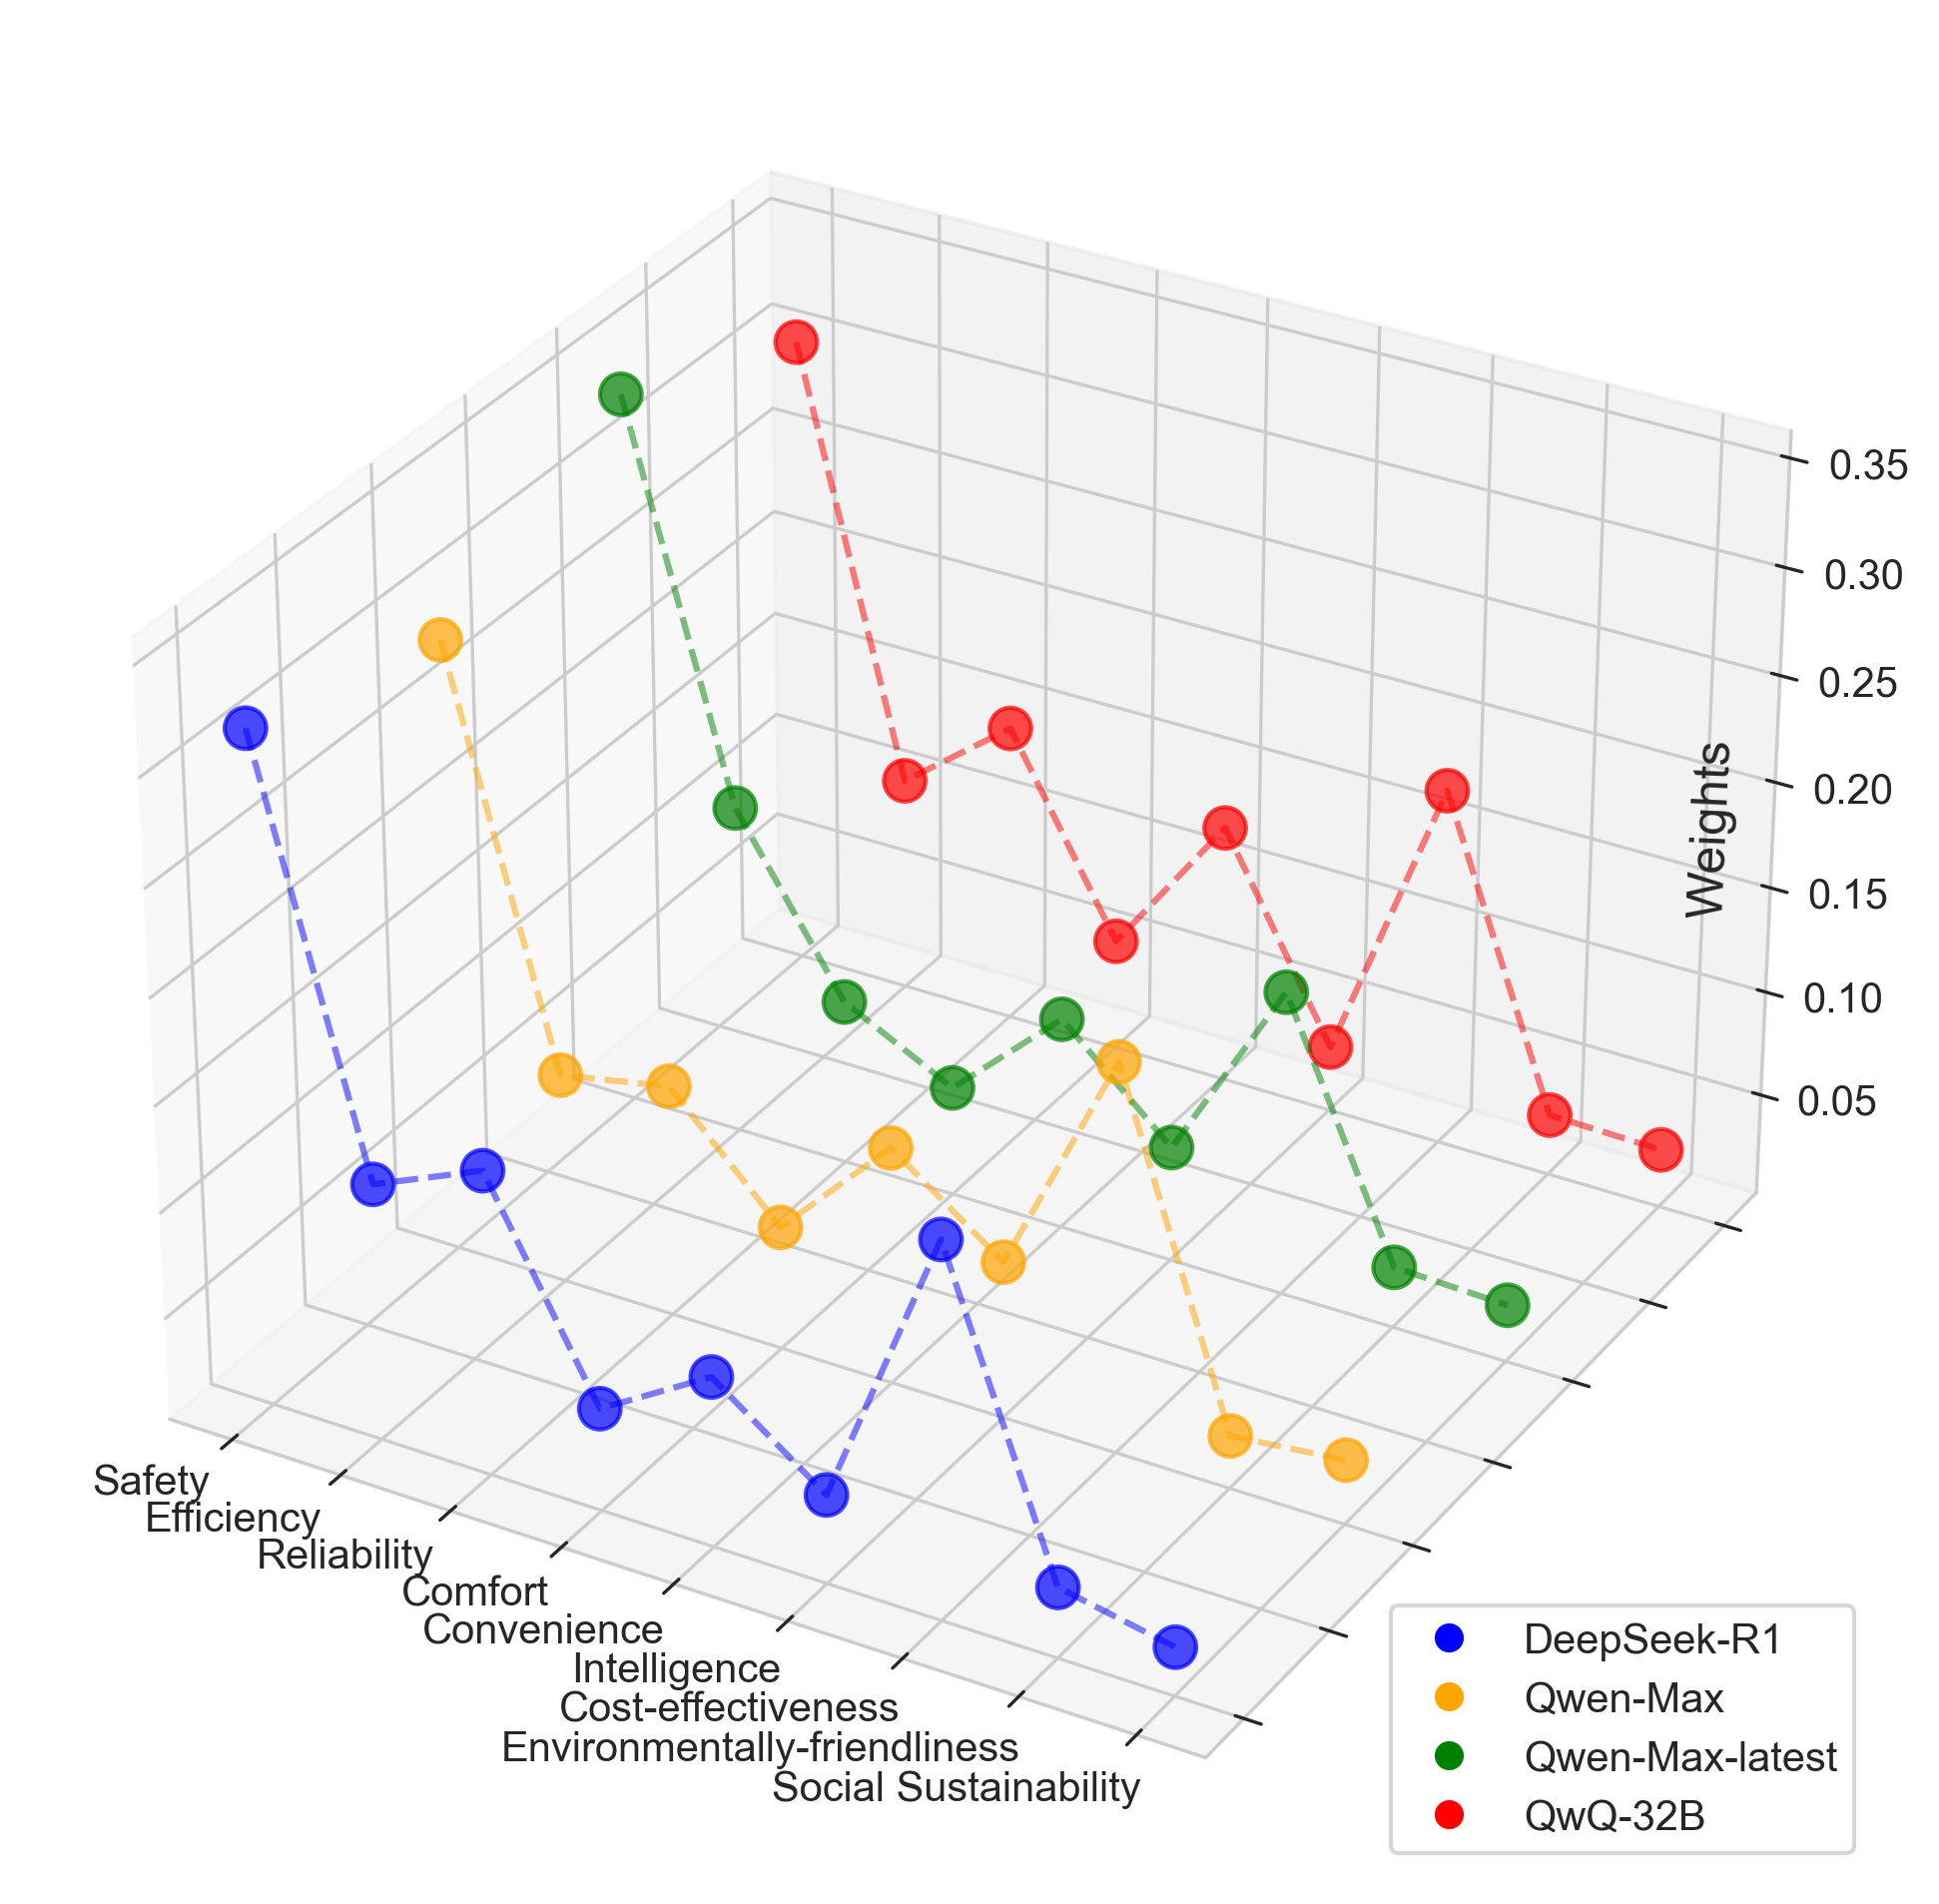

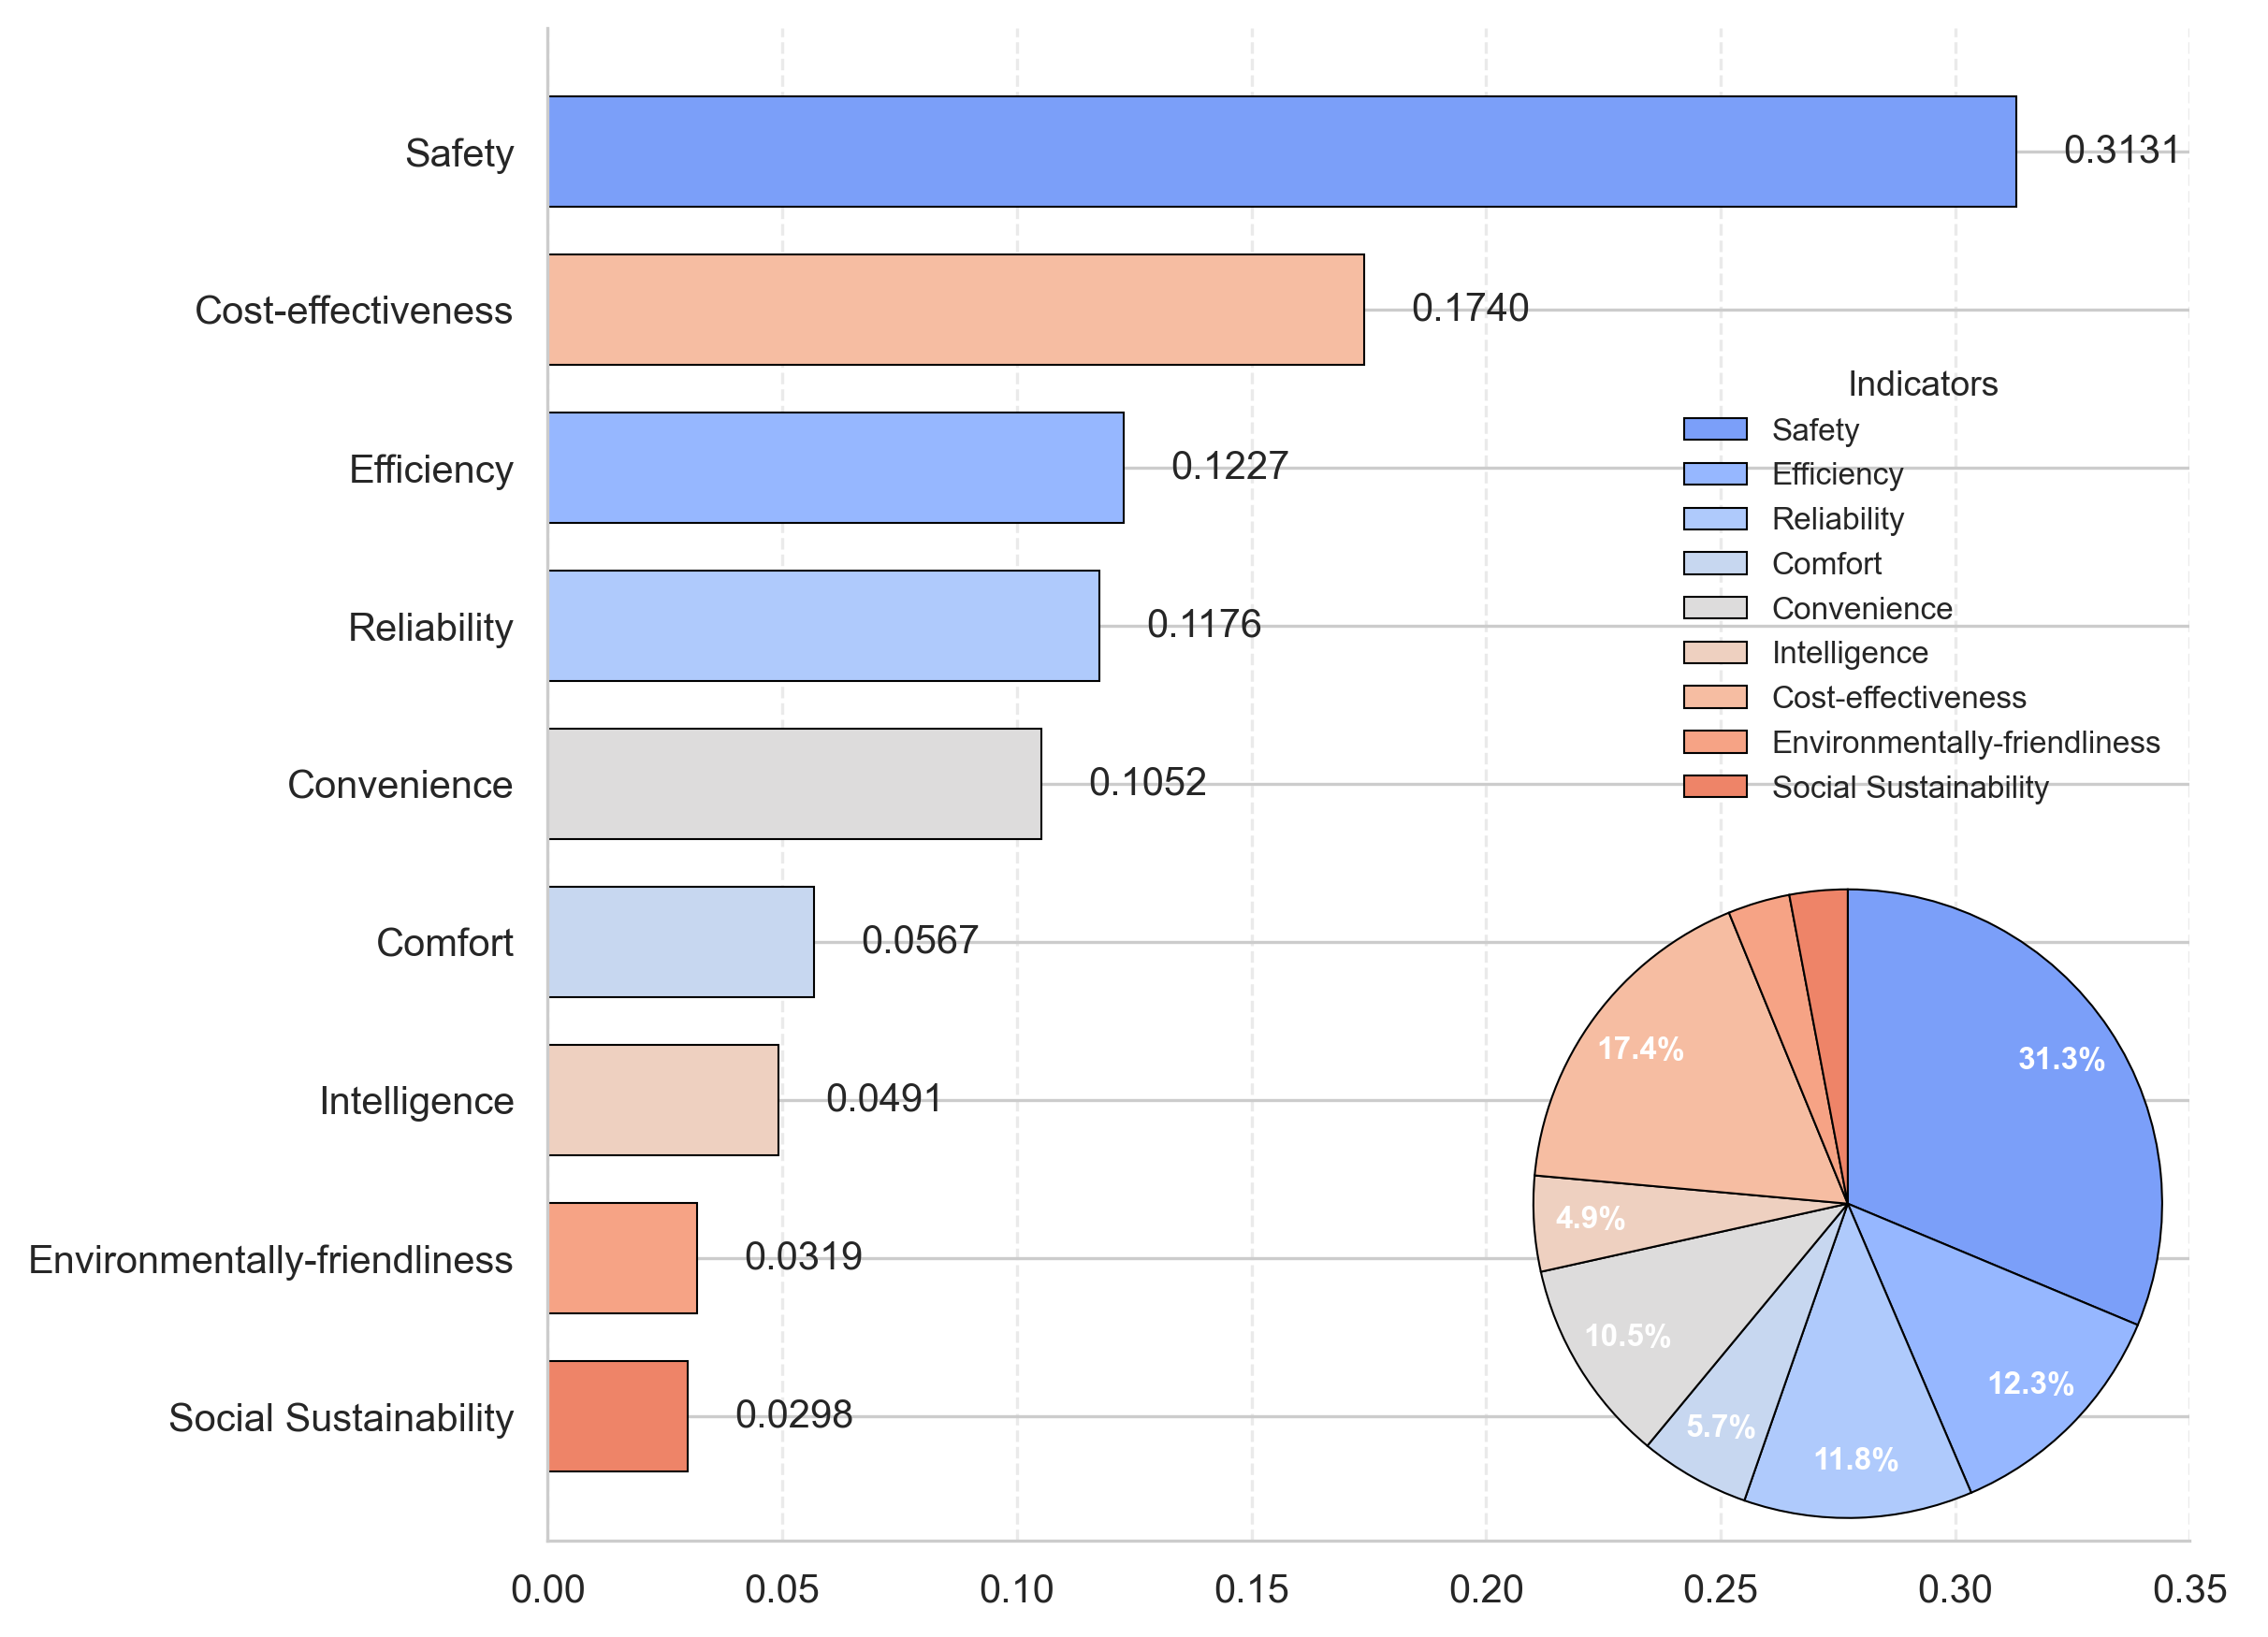

In [5]:
## Citizen
fig = plt.figure(figsize=(12, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
colors = ['blue', 'orange', 'green', 'red']
for i in range(len(citizen_weights)):
    x_values = np.arange(1, len(citizen_weights[i]) + 1)
    y_values = np.full(len(citizen_weights[i]), i + 1)
    z_values = citizen_weights[i]
    ax.scatter(
        x_values,
        y_values,
        z_values,
        label=f'Planner {i+1}',
        alpha=0.7,
        s=100,
        color=colors[i % len(colors)]
    )
    ax.plot(x_values, y_values, z_values, linestyle='--', color=colors[i % len(colors)], alpha=0.5)
ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels([],rotation=45)
ax.set_zlabel('Weights', fontsize=12, labelpad= -30,rotation=90)
ax.yaxis.set_ticklabels([],rotation=45)
for i, category in enumerate(categories):
    ax.text(i + 2, 0.13, 0.05, s=category, fontsize=10, rotation=45, ha='right', va='center')
handles = [Line2D([0], [0], marker='o', color='w', label=expert,
                  markersize=8, markerfacecolor=color)
           for expert, color in zip(experts, colors)]
ax.legend(handles = handles,fontsize=10,loc='lower right')
#plt.title("Weights of Indicators (LLMs' roles: Citizens)", fontsize=14,fontweight='semibold')
plt.show()

plt.rcParams.update({
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'figure.autolayout': False
})
sorted_idx = np.argsort(citizens)
sorted_values = citizens[sorted_idx]
sorted_labels = [categories[i] for i in sorted_idx]
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(citizens)))[sorted_idx]

fig = plt.figure(figsize=(13, 7), dpi=300)
gs = fig.add_gridspec(1, 1)
ax = fig.add_subplot(gs[0])

# Bar_Citizen
bars = ax.barh(sorted_labels, sorted_values, height=0.7, color=colors,
              edgecolor='black', linewidth=0.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}',
            va='center', ha='left', fontsize=10)
#ax.set_xlabel('Weights of Indicators', labelpad=10, fontsize=12,fontweight='semibold')
ax.set_xlim(0, 0.35)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.tick_params(axis='both', labelsize=10)
pie_ax = inset_axes(ax,
                   width=2.8,  # unit:inch
                   height=2.8,
                   loc='lower right',
                   bbox_to_anchor=(3000, 150, 0.28, 0.28))  # (x, y, width, height)

# Pie_Citizen
wedges, texts, autotexts = pie_ax.pie(
    citizens,
    colors=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(citizens))),
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'},
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    pctdistance=0.82,
    textprops={'fontsize': 8, 'color': 'white', 'fontweight': 'bold'}
)

legend = fig.legend(wedges, categories, loc='upper right',bbox_to_anchor=(0.75, 0.72),fontsize=8,ncol=1,title="Indicators",title_fontsize=9,frameon=False)
#plt.suptitle('Eventual Weights of Indicators (LLMs\'roles: Citizens) )',
         #y=0.92, fontsize=14, fontweight='semibold')
plt.subplots_adjust(left=0.3, right=0.75, top=0.88)
plt.show()

2.2 Planners

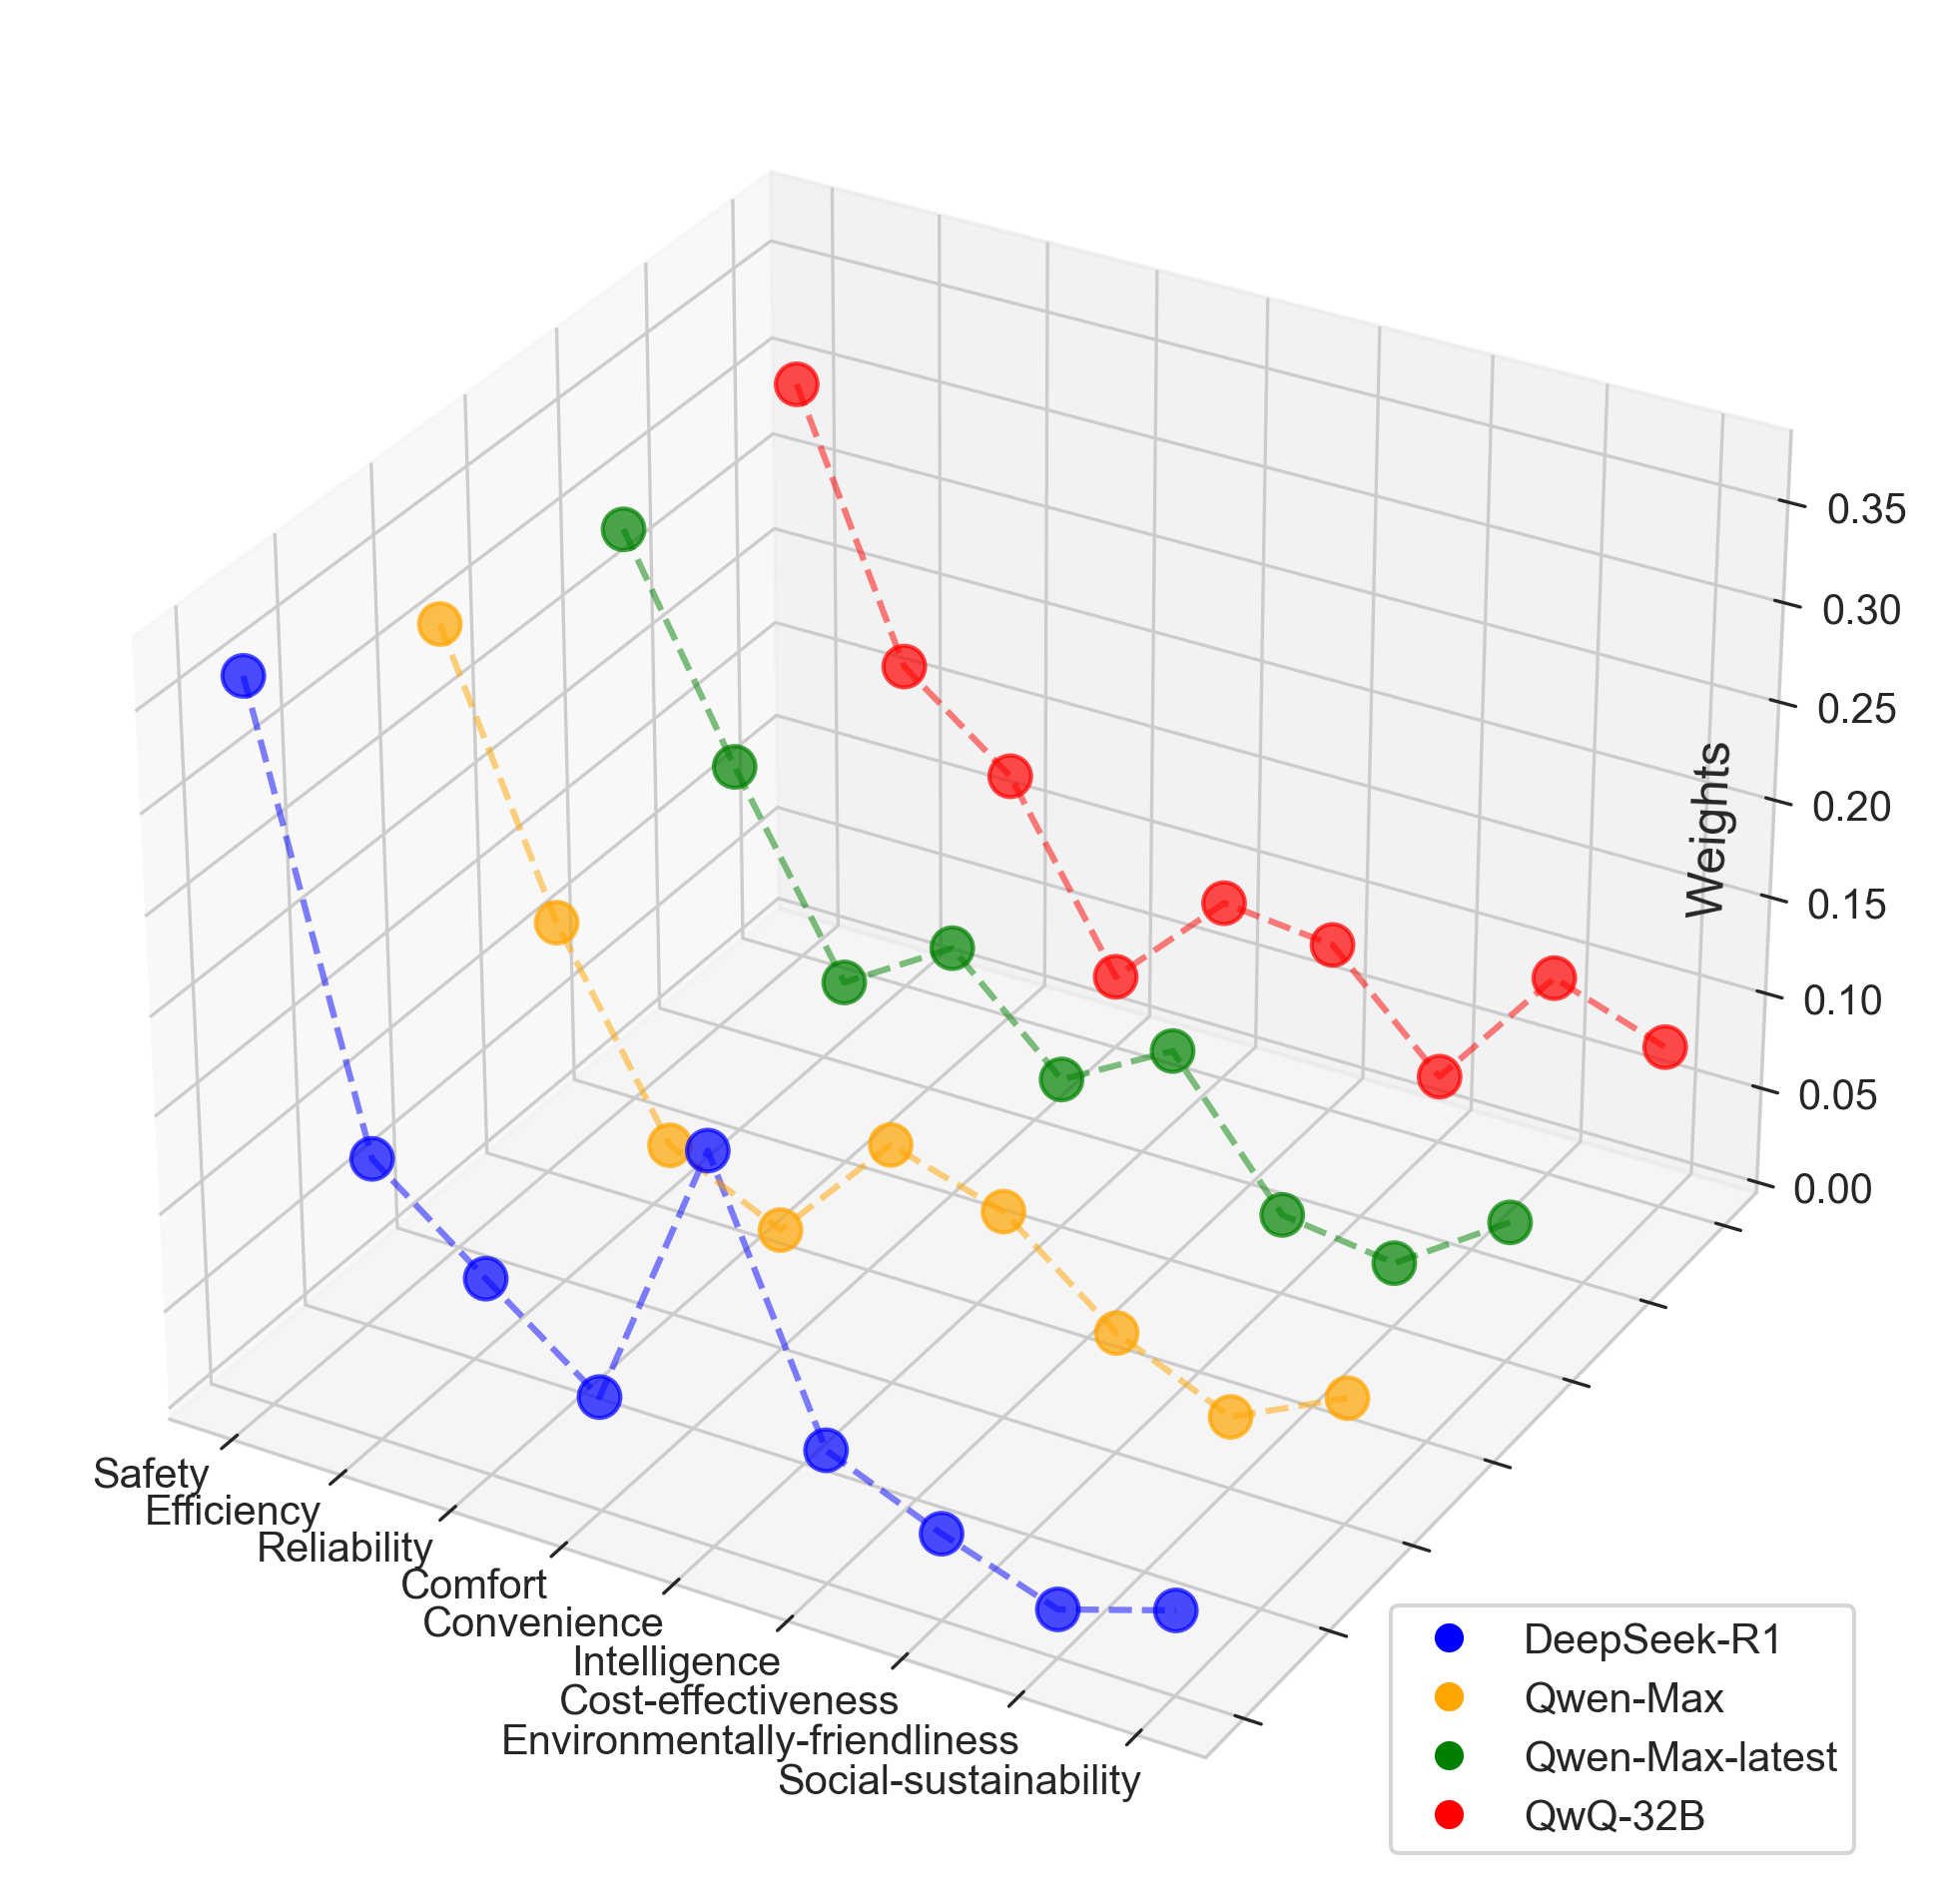

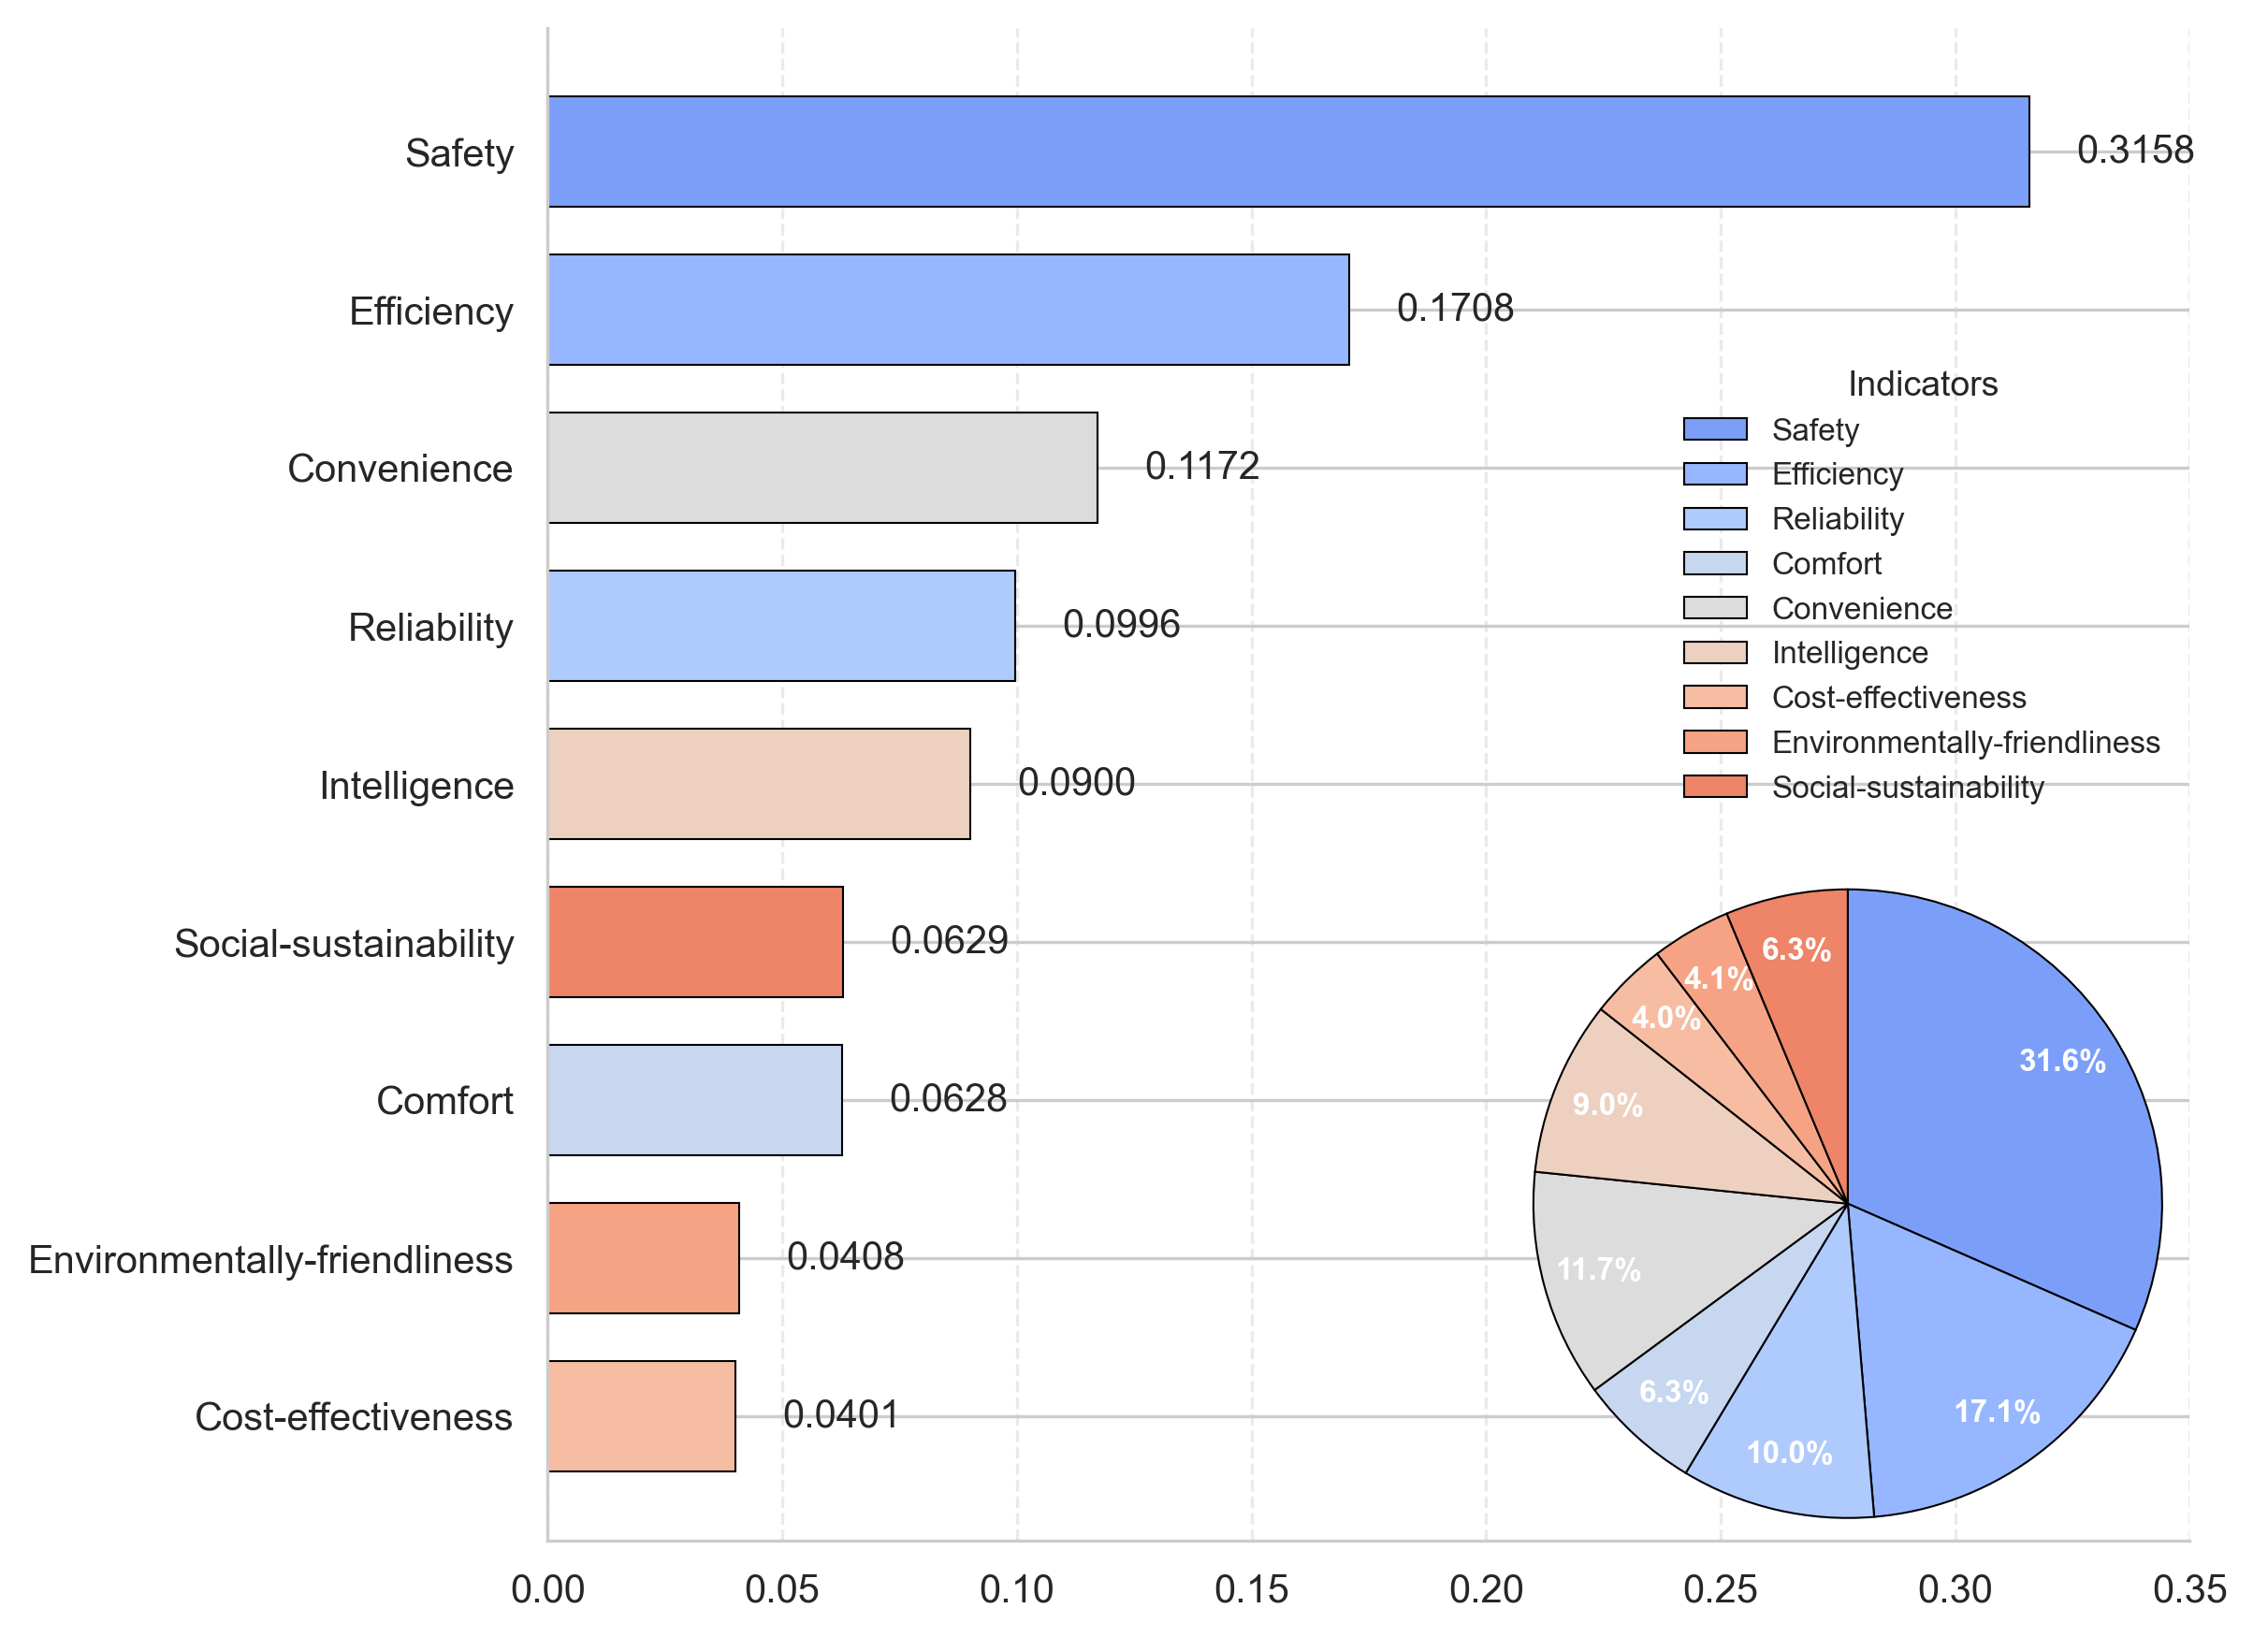

In [11]:
## Planner
fig = plt.figure(figsize=(12, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
colors = ['blue', 'orange', 'green', 'red']
for i in range(len(planner_weights)):
    x_values = np.arange(1, len(planner_weights[i]) + 1)
    y_values = np.full(len(planner_weights[i]), i + 1)
    z_values = planner_weights[i]
    ax.scatter(
        x_values,
        y_values,
        z_values,
        label=f'Planner {i+1}',
        alpha=0.7,
        s=100,
        color=colors[i % len(colors)]
    )

    ax.plot(x_values, y_values, z_values, linestyle='--', color=colors[i % len(colors)], alpha=0.5)
categories = ["Safety", "Efficiency", "Reliability", "Comfort", "Convenience", "Intelligence", "Cost-effectiveness", "Environmentally-friendliness", "Social-sustainability"]
ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels([],rotation=45)
ax.set_zlabel('Weights', fontsize=12, labelpad= -30,rotation=90)
ax.yaxis.set_ticklabels([],rotation=45)
for i, category in enumerate(categories):

    ax.text(i + 2, 0.13, 0.05, s=category, fontsize=10, rotation=45, ha='right', va='center')
experts = ["DeepSeek-R1","Qwen-Max","Qwen-Max-latest","QwQ-32B"]
handles = [Line2D([0], [0], marker='o', color='w', label=expert,
                  markersize=8, markerfacecolor=color)
           for expert, color in zip(experts, colors)]
ax.legend(handles = handles,fontsize=10,loc='lower right')
#plt.title("Weights of Indicators (LLMs' roles: Planners)", fontsize=14,fontweight='semibold')
plt.show()

plt.rcParams.update({
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'figure.autolayout': False
})
sorted_idx = np.argsort(planners)
sorted_values = planners[sorted_idx]
sorted_labels = [categories[i] for i in sorted_idx]
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(planners)))[sorted_idx]

fig = plt.figure(figsize=(13, 7), dpi=300)
gs = fig.add_gridspec(1, 1)
ax = fig.add_subplot(gs[0])

# Bar_Planner
bars = ax.barh(sorted_labels, sorted_values, height=0.7, color=colors,
              edgecolor='black', linewidth=0.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}',
            va='center', ha='left', fontsize=10)
#ax.set_xlabel('Weights of Indicators', labelpad=10, fontsize=12,fontweight='semibold')
ax.set_xlim(0, 0.35)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.tick_params(axis='both', labelsize=10)
pie_ax = inset_axes(ax,
                   width=2.8,
                   height=2.8,
                   loc='lower right',
                   bbox_to_anchor=(3000, 150, 0.28, 0.28))

# Pie_Planner
wedges, texts, autotexts = pie_ax.pie(
    planners,
    colors=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(planners))),
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'},
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    pctdistance=0.82,
    textprops={'fontsize': 8, 'color': 'white', 'fontweight': 'bold'}
)

legend = fig.legend(wedges, categories, loc='upper right',bbox_to_anchor=(0.75, 0.72),fontsize=8,ncol=1,title="Indicators",title_fontsize=9,frameon=False)
#plt.suptitle('Eventual Weights of Indicators (LLMs\'roles: Planners) )',
         #y=0.92, fontsize=14, fontweight='semibold')
plt.subplots_adjust(left=0.3, right=0.75, top=0.88)
plt.show()

3、爬虫词云(已去掉)

4. score distribution

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 设置 Matplotlib 中文字体
plt.rcParams["font.sans-serif"] = ['Arial', 'sans-serif']
plt.rcParams["axes.unicode_minus"] = False

# 设置数据文件夹和输出文件夹
data_dir = "classNoNe_ScoreNe"
output_dir = "score_distribution_plots2"
os.makedirs(output_dir, exist_ok=True)

# 获取所有 JSON 文件
json_files_all = [f for f in os.listdir(data_dir) if f.endswith(".json")]

# 定义绘图顺序
categories = ["Safety", "Efficiency", "Reliability", "Comfort", "Convenience", "Intelligence", "Cost-effectiveness", "Environmentally-friendliness", "Social-sustainability"]

# 创建一个文件名到索引的映射
filename_to_index = {cat + ".json": i for i, cat in enumerate(categories)}

# 过滤并排序 JSON 文件
json_files_to_plot = []
for filename in json_files_all:
    if filename in filename_to_index:
        json_files_to_plot.append(filename)

# Sort the json files based on the categories order
json_files_to_plot.sort(key=lambda filename: filename_to_index.get(filename, float('inf')))

# 确保只处理前9个文件（在排序后）
if len(json_files_to_plot) > 9:
    print("警告：超过9个匹配的JSON文件，只处理前9个。")
    json_files_to_plot = json_files_to_plot[:9]

# 分数区间（0-100，每 5 分一个区间）
score_bins = list(range(0, 105, 5))

# 创建一个大图，包含 3x3 的子图布局
fig, axes = plt.subplots(3, 3, figsize=(18, 10),dpi=300)
axes = axes.ravel()  # 将 3x3 的子图数组展平为一维数组

# 遍历每个 JSON 文件
for idx, json_file in enumerate(json_files_to_plot):
    file_path = os.path.join(data_dir, json_file)

    # 读取 JSON 数据
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 提取所有 score
    scores = [obj.get("score", 0) for obj in data if isinstance(obj.get("score"), (int, float))]
    if not scores:
        print(f"{json_file} 没有有效的分数数据，跳过绘图。")
        continue

    # 统计分数分布
    score_counts, _ = np.histogram(scores, bins=score_bins)

    # 在当前子图上绘制柱状图
    sns.histplot(scores, bins=score_bins, kde=False, color="blue", edgecolor="black", alpha=0.6 , ax=axes[idx])

    # 画核密度估计（KDE）曲线（可选）
    #sns.kdeplot(scores, color="red", linewidth=2, label="核密度估计", ax=axes[idx])

    # 拟合正态分布曲线（可选）
    mu, sigma = norm.fit(scores)  # 计算均值和标准差
    x = np.linspace(0, 100, 100)
    y = norm.pdf(x, mu, sigma) * len(scores) * 5  # 乘以样本数量和 bin 宽度，匹配柱状图尺度
    axes[idx].plot(x, y, color="green", linestyle="--", linewidth=2, label=f"Normal Distribution Fitting Curve ($\mu={mu:.2f}$, $\sigma={sigma:.2f}$)")

    # 设置图表信息
    axes[idx].set_xlabel("Score")
    axes[idx].set_ylabel("Number of Comments")
    axes[idx].set_title(f"Score Distribution of Indicator:\'{json_file.replace('.json', '')}\'")
    axes[idx].set_xticks(score_bins)
    axes[idx].set_xticklabels(score_bins, rotation=45)
    axes[idx].grid(axis="y", linestyle="--", alpha=0.7)
    axes[idx].legend()

# 调整子图之间的间距
plt.tight_layout()

# 保存图像
output_path = os.path.join(output_dir, "all_scores_distribution.png")
plt.savefig(output_path, dpi=300)
plt.close()

print(f"所有分数分布图已保存至 {output_path}")

所有分数分布图已保存至 score_distribution_plots2/all_scores_distribution.png


5. avg score rose distribution

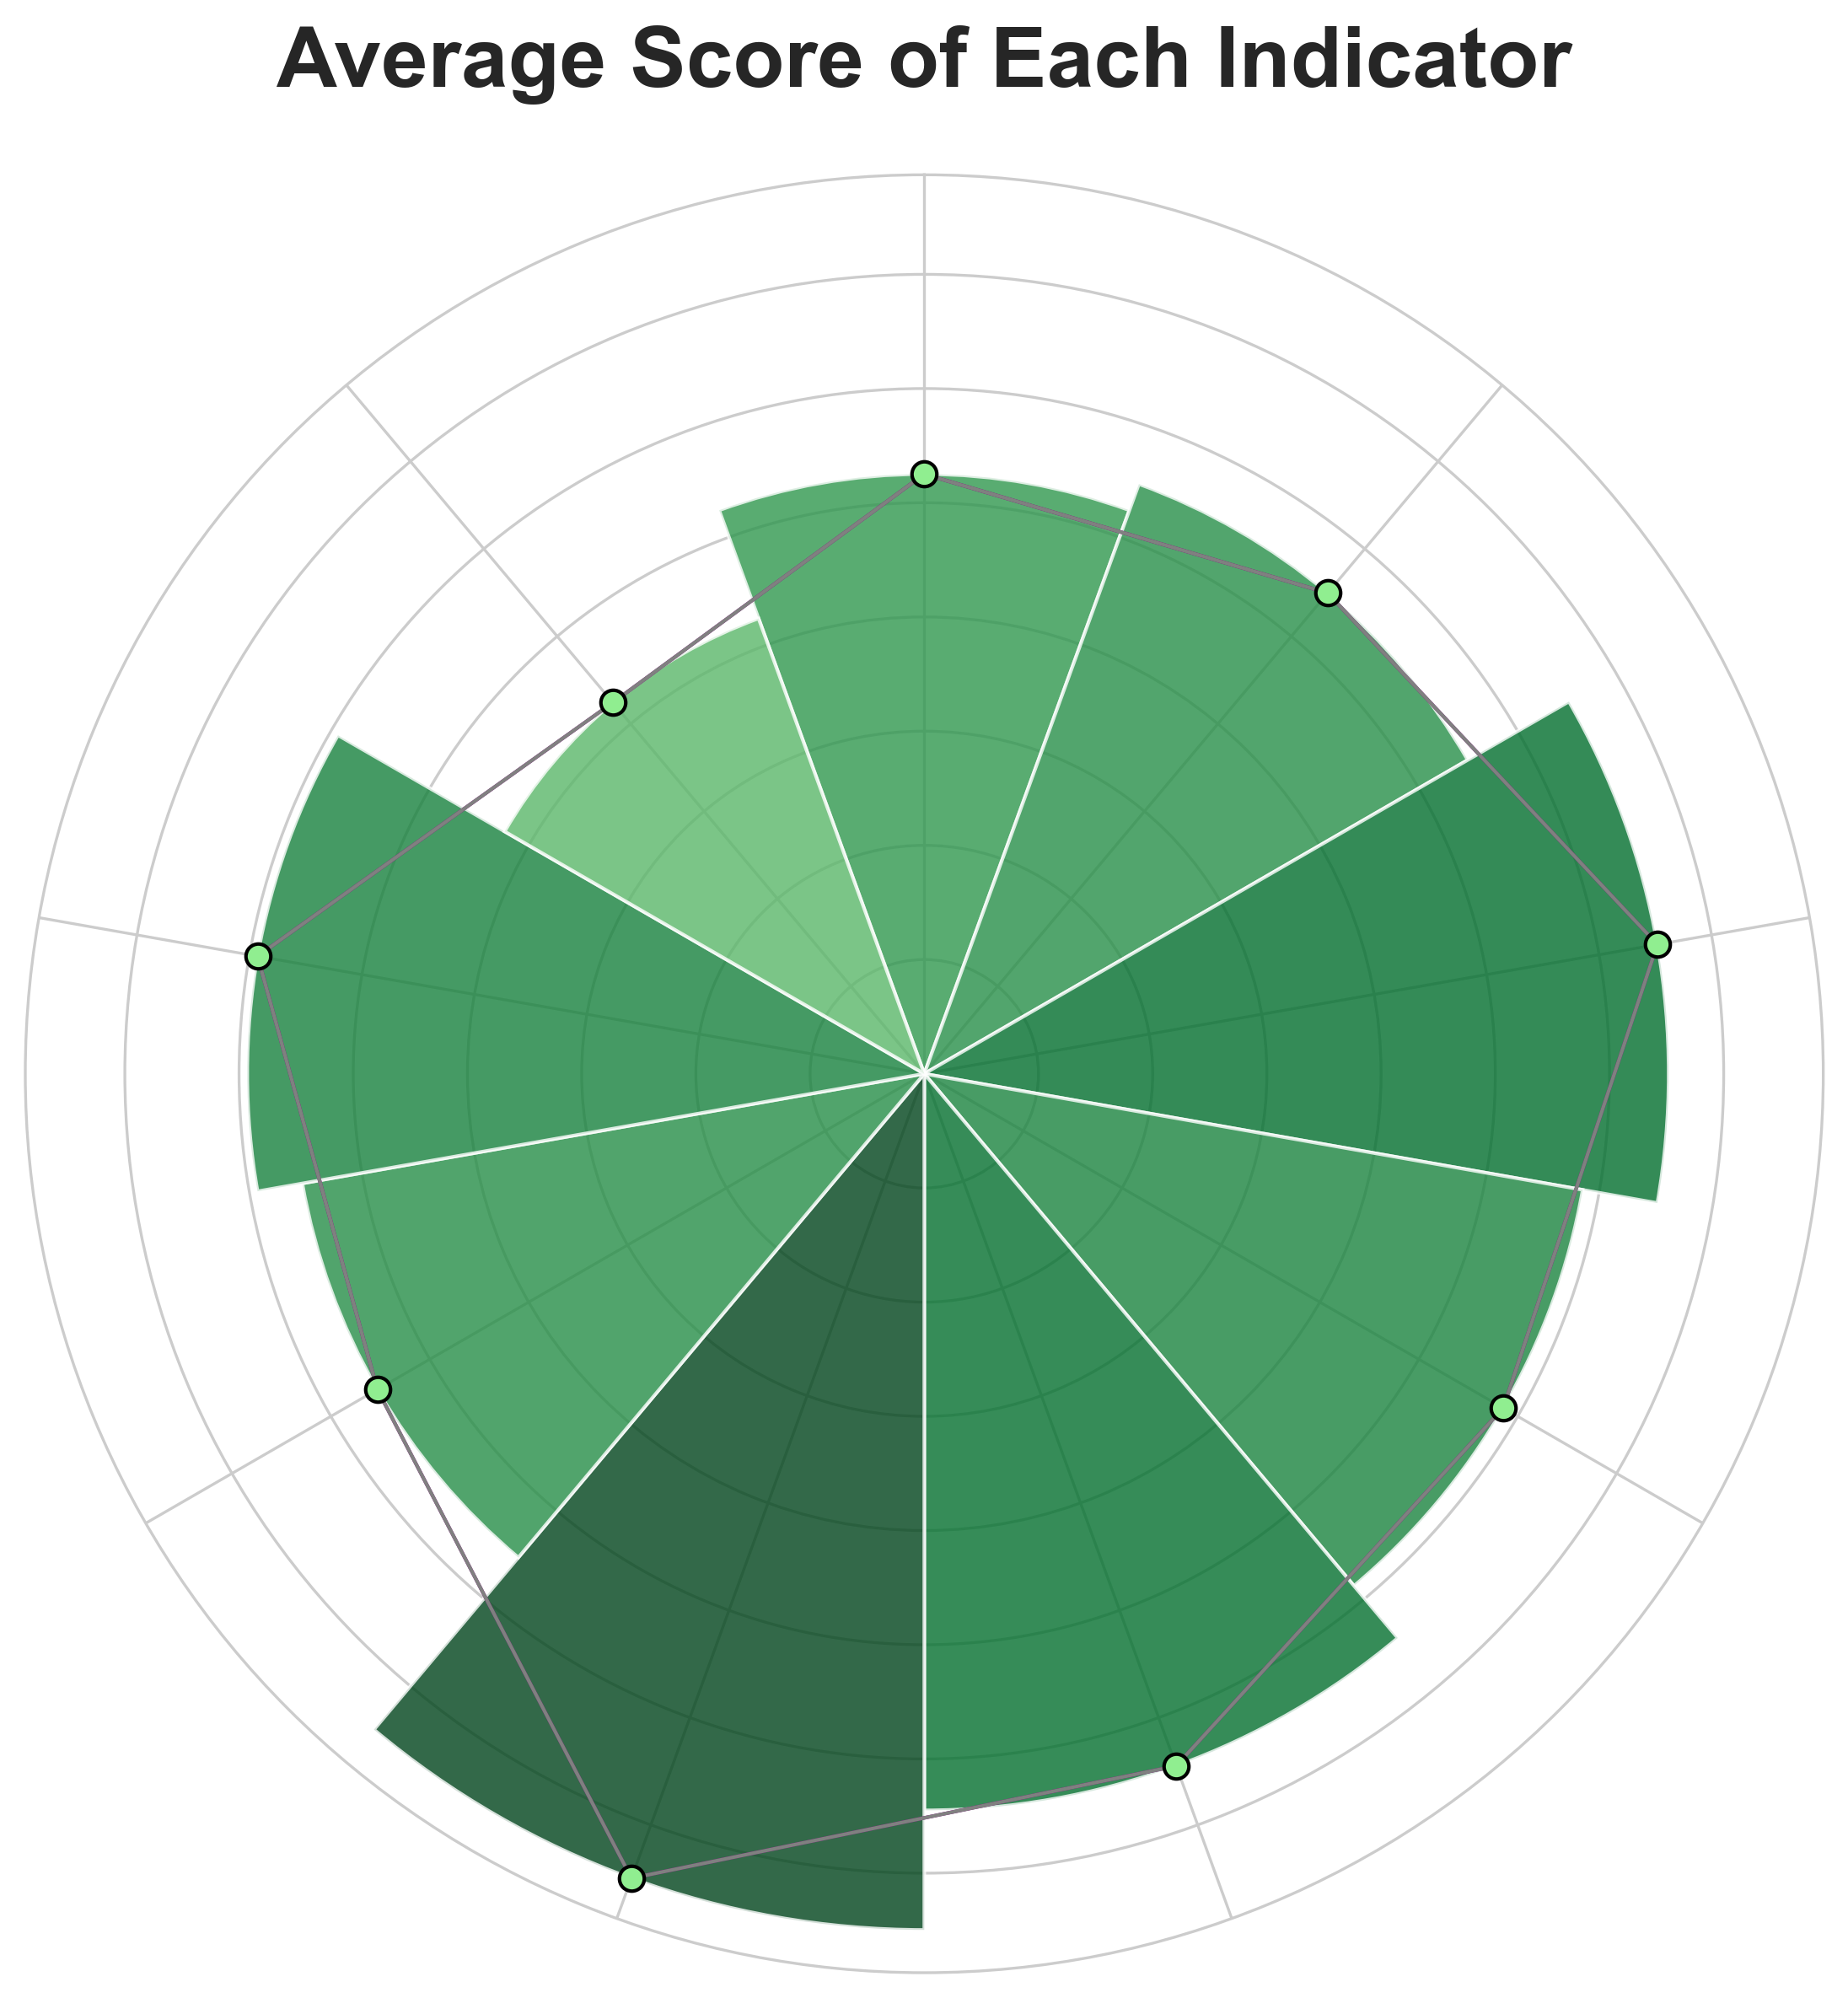

玫瑰图已保存至 score_distribution_plots2/score_distribution_rose_plot.png


In [12]:
avg = [round(float(value), 2) for value in avg]
data_dir = "NEclassification_result_0307"
output_dir = "score_distribution_plots2"
os.makedirs(output_dir, exist_ok=True)

N = len(avg)
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = np.array(avg)  # 将 radii 转换为 NumPy 数组
width = 2 * np.pi / N

fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': 'polar'}, dpi=300)
bars = ax.bar(theta, radii, width=width, bottom=0.0)

# 设置浅绿色调
colors = plt.cm.Greens(radii / max(radii))  # 改为 Greens 颜色映射
for bar, color in zip(bars, colors):
    bar.set_facecolor(color)
    bar.set_alpha(0.8)

# 设置图表信息
ax.set_title("Average Score of Each Indicator", va='bottom', fontsize=24, fontweight='bold', pad=20)
ax.set_theta_zero_location('N')  # 设置起始角度
ax.set_theta_direction(-1)  # 设置顺时针方向
ax.set_xticks(np.linspace(0, 2 * np.pi, 9, endpoint=False))  # 修改为9等分
ax.set_xticklabels([])  # 去掉角度标签
ax.set_yticklabels([])  # 去掉分数标签

# 连接扇区最外侧的中间点形成九边形
outer_points = [(angle, radius) for angle, radius in zip(theta, radii)]
outer_points.append((theta[0], radii[0]))  # 闭合多边形
x = [point[0] for point in outer_points]
y = [point[1] for point in outer_points]
ax.plot(x, y, color='purple', linestyle='-', linewidth=1)

# 设置底图为九边形
for i in range(N):
    ax.plot([theta[i], theta[(i + 1) % N]], [radii[i], radii[(i + 1) % N]], color='gray', linewidth=1)

# 突出显示折线上的点
ax.scatter(theta, radii, color='lightgreen', edgecolors='black', s=50, zorder=3)

# 调整布局并保存图像
plt.tight_layout()
output_path = os.path.join(output_dir, "score_distribution_rose_plot.png")
plt.savefig(output_path, dpi=600)
plt.show()

print(f"玫瑰图已保存至 {output_path}")
